In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from episbi.models import Transition, compartment_model
from episbi.prior import UniformPrior
from episbi.inference import SBIEngine
from episbi import simulate_for_sbi
from episbi.metric import evaluate_prediction_windows
from episbi.utils import plot_prediction_windows

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
model_type = "deterministic"
simulator_extra_kwargs = {"observation_error": "poisson"}

initial_conditions = {"S": 99_990, "E": 0, "I": 10, "R": 0}
theta_true = {"beta": 0.80, "kappa": 0.30, "gamma": 0.35}
total_days = 100
inference_days = 80
forecast_days = total_days - inference_days
output_name = "E_to_I"

In [3]:
compartments = ["S", "E", "I", "R"]
transitions = [
    Transition("S", "E", "beta * S * I / N", name="S_to_E"),
    Transition("E", "I", "kappa * E", name="E_to_I"),
    Transition("I", "R", "gamma * I", name="I_to_R"),
]
param_names = ["beta", "kappa", "gamma"]
observed = {"transitions": [output_name]}

In [4]:
seir_model = compartment_model(
    compartments=compartments,
    transitions=transitions,
    param_names=param_names,
    model_type=model_type,
    initial_conditions=initial_conditions,
    observed=observed,
)

print(seir_model.show())

Model type: deterministic
Compartments: S, E, I, R
Parameters: beta, kappa, gamma
Transitions:
  S_to_E: S -> E, rate=beta * S * I / N
  E_to_I: E -> I, rate=kappa * E
  I_to_R: I -> R, rate=gamma * I
Observed:
  E_to_I


In [5]:
prior = UniformPrior(
    bounds={
        "beta": (0.01, 1.5),
        "kappa": (0.01, 0.5),
        "gamma": (0.01, 0.5),
    }
)

In [7]:
observed_result = seir_model(
    theta_true,
    total_days=total_days,
    seed=0,
    **simulator_extra_kwargs,
)
observed = observed_result[output_name]
obs_train = observed[:inference_days]

observed.shape, obs_train.shape

((100,), (80,))

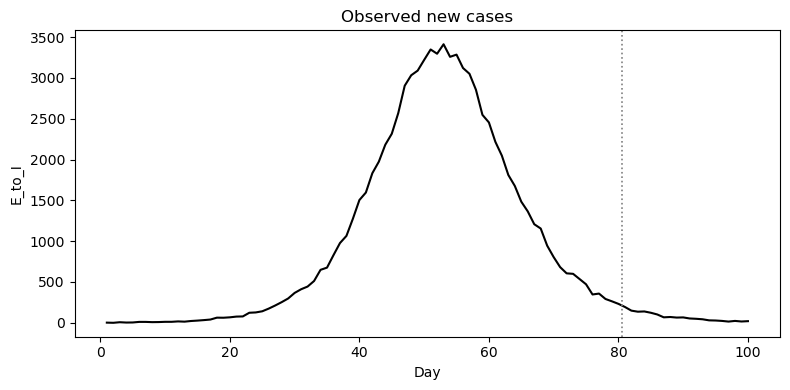

In [8]:
days = np.arange(1, total_days + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days, observed, color="black", linewidth=1.5)
ax.axvline(inference_days + 0.5, color="gray", linestyle=":", linewidth=1.2)
ax.set_xlabel("Day")
ax.set_ylabel(output_name)
ax.set_title(f"Observed new cases")
fig.tight_layout()
plt.show()

## Inference - ABC

In [9]:
engine = SBIEngine()
posterior_samples, history = engine.run_abc(
    obs_data={output_name: obs_train},
    prior=prior,
    simulator_func=seir_model,
    simulator_kwargs={"total_days": inference_days, **simulator_extra_kwargs},
    num_simulations=100_000,
    population_size=1_000,
    num_samples=1_000,
)

ABC.Sampler INFO: Parallelize sampling on 128 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-06-18 13:13:42>
ABC INFO: Calibration sample t = -1.


[*] Running SMC-ABC...


ABC.Population INFO: Recording also rejected particles: True
ABC INFO: t: 0, eps: 1.08141706e+01.
ABC INFO: Accepted: 1000 / 5034 = 1.9865e-01, ESS: 1.0000e+03.
ABC INFO: t: 1, eps: 3.82895467e+00.
ABC INFO: Accepted: 1000 / 4517 = 2.2139e-01, ESS: 9.3442e+02.
ABC INFO: t: 2, eps: 4.12077385e+00.
ABC INFO: Accepted: 1000 / 8454 = 1.1829e-01, ESS: 8.3021e+02.
ABC INFO: t: 3, eps: 4.46426941e+00.
ABC INFO: Accepted: 1000 / 18397 = 5.4357e-02, ESS: 7.8509e+02.
ABC INFO: t: 4, eps: 4.20722280e+00.
ABC INFO: Accepted: 1000 / 48890 = 2.0454e-02, ESS: 6.7438e+02.
ABC INFO: t: 5, eps: 4.30448926e+00.
ABC INFO: Accepted: 1000 / 138983 = 7.1951e-03, ESS: 3.2496e+02.
ABC INFO: Stop: Total simulations budget.
ABC.History INFO: Done <ABCSMC id=1, duration=0:01:36.028002, end_time=2026-06-18 13:15:18>


In [10]:
param_df = pd.DataFrame(posterior_samples, columns=prior.names)
param_df.describe()

,beta,kappa,gamma
count,1000.000000,1000.000000,1000.000000
mean,0.832330,0.306295,0.347170
std,0.218165,0.102427,0.079890
min,0.326674,0.078490,0.164111
25%,0.662168,0.231990,0.284015
50%,0.826819,0.285071,0.343879
75%,0.993243,0.375183,0.406185
max,1.487536,0.621708,0.564375


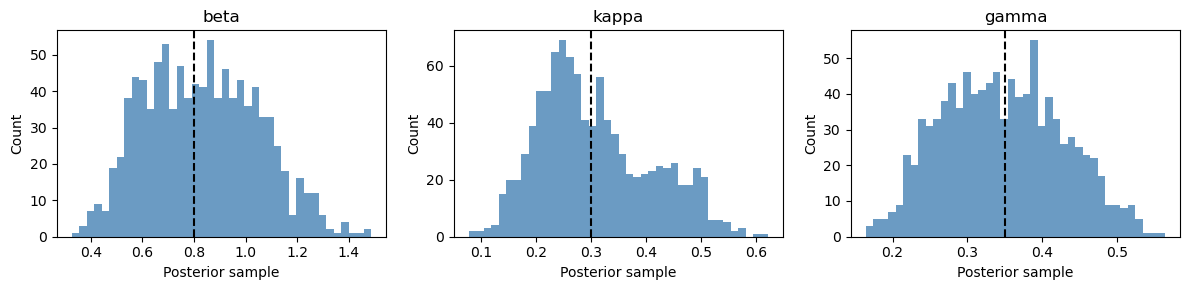

In [11]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    ax.axvline(theta_true[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

In [12]:
posterior_predictive = []

for _, theta in param_df.iloc[:300].iterrows():
    theta_dict = prior.to_dict(theta)
    sim = seir_model(
        theta_dict,
        total_days=total_days,
        **simulator_extra_kwargs,
    )[output_name]
    posterior_predictive.append(sim)

posterior_predictive = np.stack(posterior_predictive)[:, :, None]
posterior_predictive.shape

(300, 100, 1)

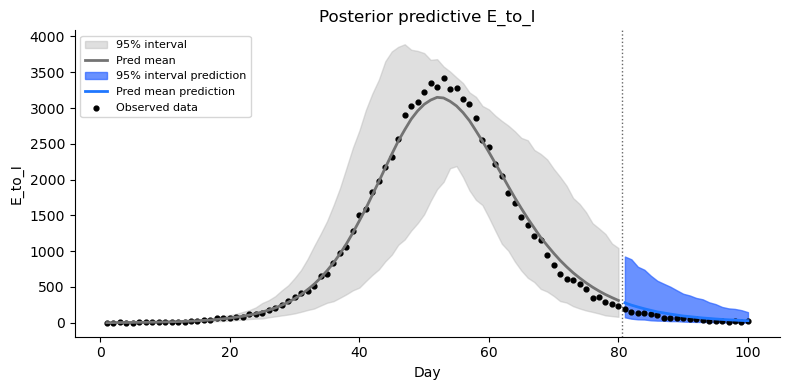

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_prediction_windows(
    y_obs=observed[:, None],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_index=0,
    title=f"Posterior predictive {output_name}",
    ylabel=output_name,
    ax=ax,
)
fig.tight_layout()
plt.show()

In [14]:
ppc_result = evaluate_prediction_windows(
    y_obs=observed[:,None],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_names=["incidence"],
)

ppc_result

,window,output,MAE,RMSE,PI95_coverage,interval_score,WIS
0,inference,incidence,28.45625,46.703285,1.0,1102.826875,265.101018
1,forecast,incidence,7.45000,11.001136,1.0,428.538750,75.222598
